In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from src.points import reconstruction_from_dataset
dataset_name = "stereo_tambor"

Iniciando procesamiento de 17 pares de imágenes...
--- Presiona 'ESC' en las ventanas de imagen para saltar al final ---

--- Procesando Frame 1/17 ---
*************** EP Error ***************
EP Error /onnxruntime_src/onnxruntime/core/providers/cuda/cuda_call.cc:129 std::conditional_t<THRW, void, onnxruntime::common::Status> onnxruntime::CudaCall(ERRTYPE, const char*, const char*, SUCCTYPE, const char*, const char*, int) [with ERRTYPE = cudaError; bool THRW = true; SUCCTYPE = cudaError; std::conditional_t<THRW, void, common::Status> = void] /onnxruntime_src/onnxruntime/core/providers/cuda/cuda_call.cc:121 std::conditional_t<THRW, void, onnxruntime::common::Status> onnxruntime::CudaCall(ERRTYPE, const char*, const char*, SUCCTYPE, const char*, const char*, int) [with ERRTYPE = cudaError; bool THRW = true; SUCCTYPE = cudaError; std::conditional_t<THRW, void, common::Status> = void] CUDA failure 35: CUDA driver version is insufficient for CUDA runtime version ; GPU=-1 ; hostname=juanchi-

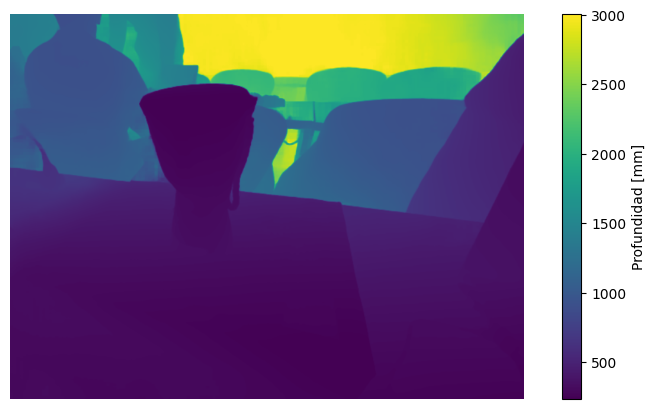

(i) POSE OK. Posición de cámara (X,Y,Z en milimetros): [-164.7   289.78 -223.04]
(i) PUNTOS 3D generados en este frame: 480000

--- Procesando Frame 2/17 ---


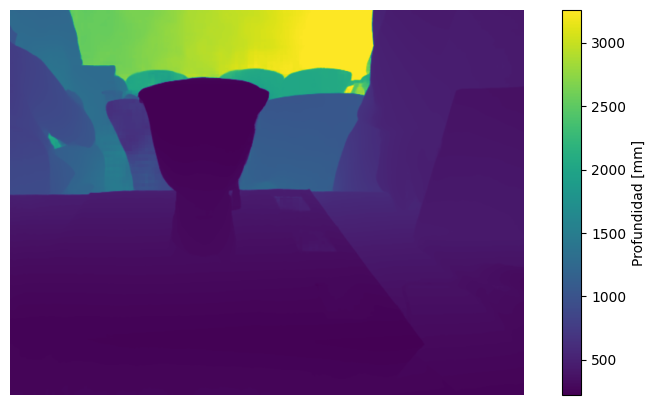

(i) POSE OK. Posición de cámara (X,Y,Z en milimetros): [-153.55  192.5  -217.51]
(i) PUNTOS 3D generados en este frame: 480000

--- Procesando Frame 3/17 ---


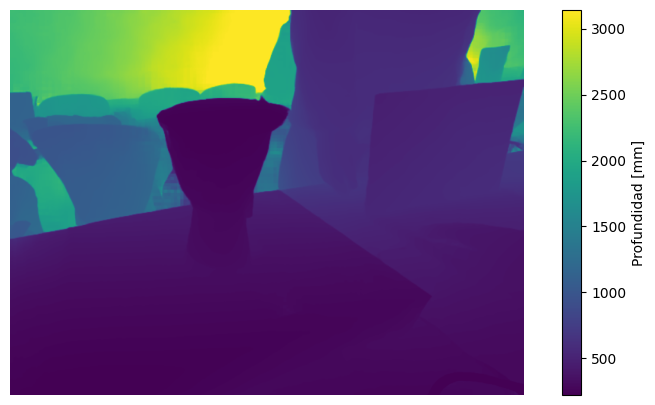

(i) POSE OK. Posición de cámara (X,Y,Z en milimetros): [-143.1    94.91 -224.18]
(i) PUNTOS 3D generados en este frame: 480000

--- Procesando Frame 4/17 ---


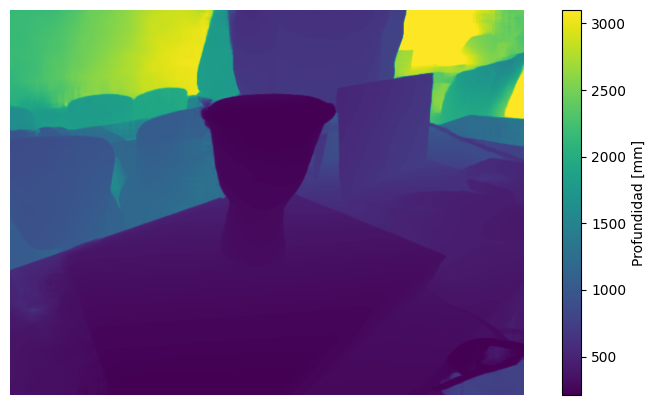

(i) POSE OK. Posición de cámara (X,Y,Z en milimetros): [ -84.99   -0.76 -221.45]
(i) PUNTOS 3D generados en este frame: 480000

--- Procesando Frame 5/17 ---


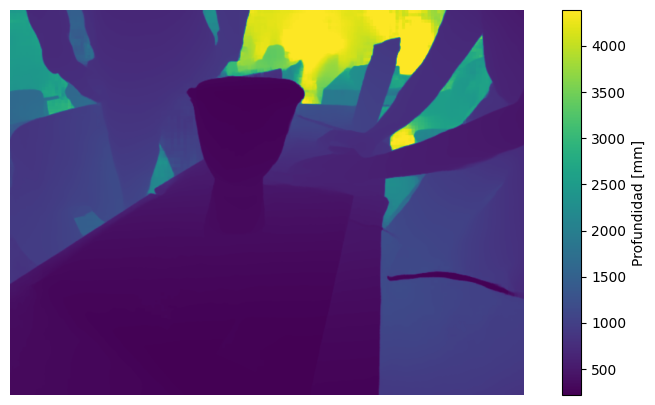

(i) POSE OK. Posición de cámara (X,Y,Z en milimetros): [   2.06 -106.   -211.85]
(i) PUNTOS 3D generados en este frame: 480000

--- Procesando Frame 6/17 ---


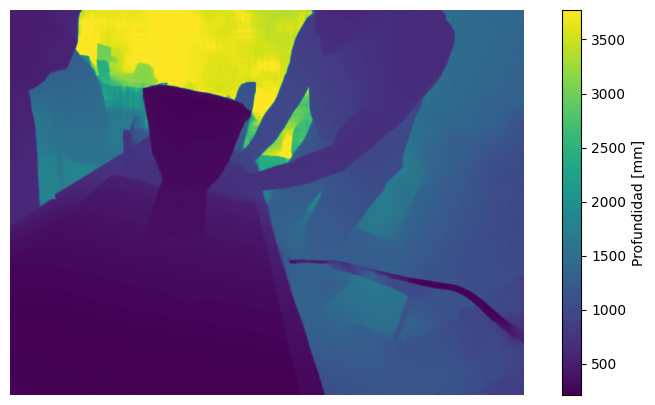

(i) POSE OK. Posición de cámara (X,Y,Z en milimetros): [  89.08 -139.58 -199.  ]
(i) PUNTOS 3D generados en este frame: 480000

--- Procesando Frame 7/17 ---


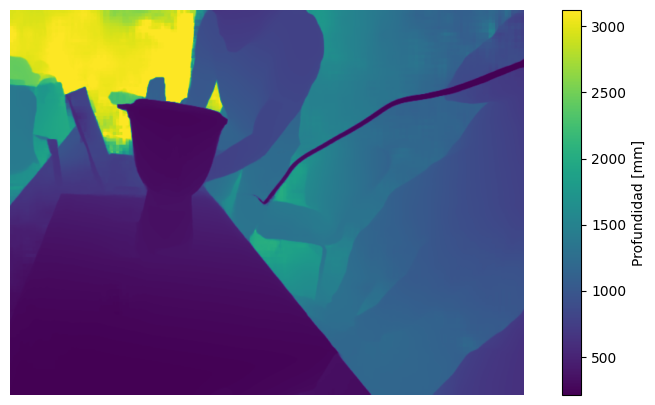

(i) POSE OK. Posición de cámara (X,Y,Z en milimetros): [ 188.65 -137.63 -206.39]
(i) PUNTOS 3D generados en este frame: 480000

--- Procesando Frame 8/17 ---


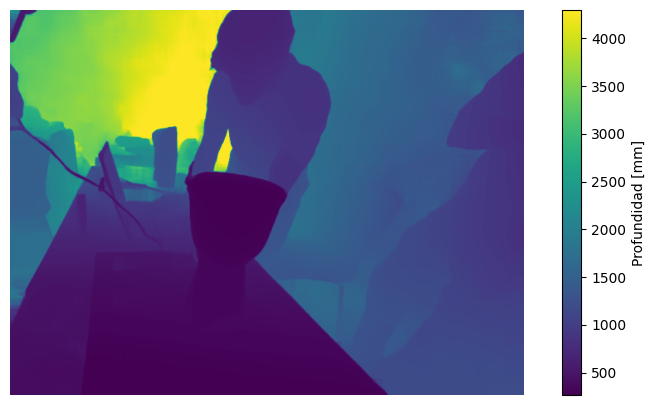

(i) POSE OK. Posición de cámara (X,Y,Z en milimetros): [ 254.3   -93.89 -238.08]
(i) PUNTOS 3D generados en este frame: 480000

--- Procesando Frame 9/17 ---


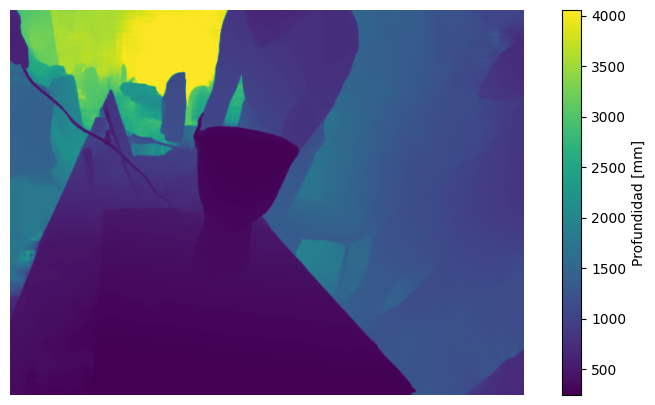

(i) POSE OK. Posición de cámara (X,Y,Z en milimetros): [ 252.38  -93.94 -241.14]
(i) PUNTOS 3D generados en este frame: 480000

--- Procesando Frame 10/17 ---


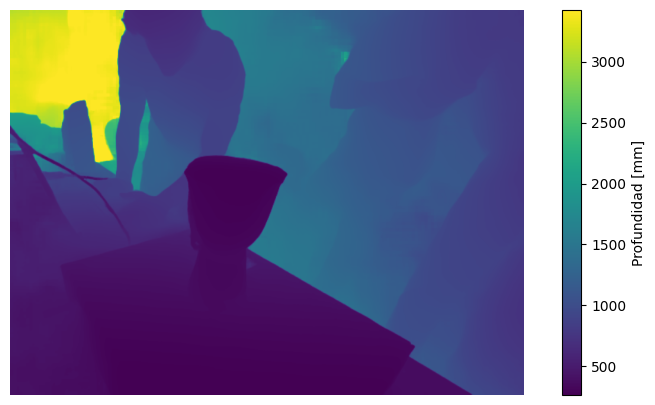

(i) POSE OK. Posición de cámara (X,Y,Z en milimetros): [ 343.33  -29.99 -246.47]
(i) PUNTOS 3D generados en este frame: 480000

--- Procesando Frame 11/17 ---


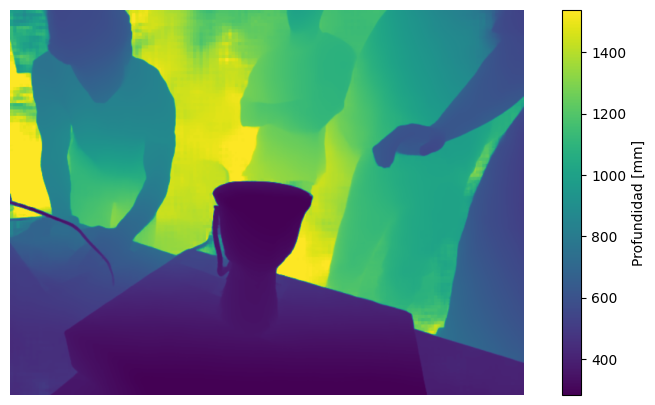

(i) POSE OK. Posición de cámara (X,Y,Z en milimetros): [ 435.8    92.87 -257.38]
(i) PUNTOS 3D generados en este frame: 480000

--- Procesando Frame 12/17 ---


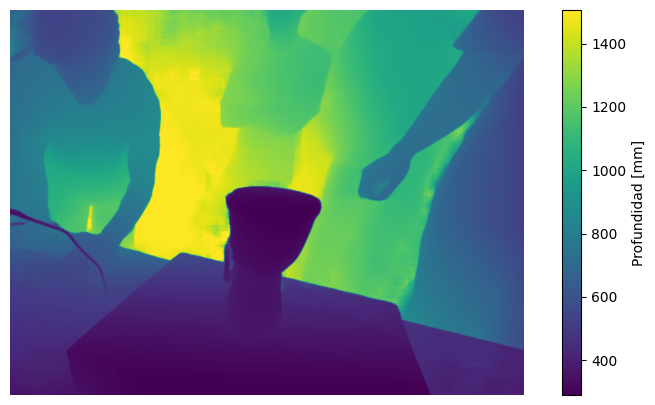

(i) POSE OK. Posición de cámara (X,Y,Z en milimetros): [ 455.64  138.76 -263.47]
(i) PUNTOS 3D generados en este frame: 480000

--- Procesando Frame 13/17 ---


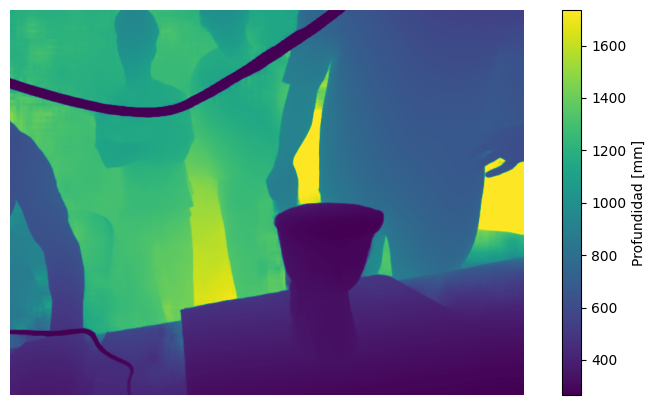

(i) POSE OK. Posición de cámara (X,Y,Z en milimetros): [ 424.62  361.93 -282.94]
(i) PUNTOS 3D generados en este frame: 480000

--- Procesando Frame 14/17 ---


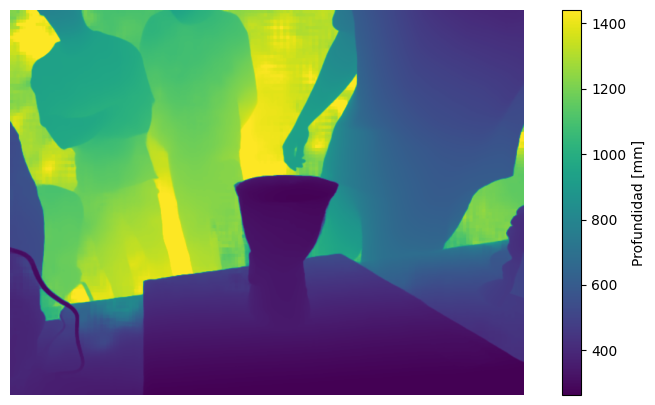

(i) POSE OK. Posición de cámara (X,Y,Z en milimetros): [ 424.51  353.38 -242.96]
(i) PUNTOS 3D generados en este frame: 480000

--- Procesando Frame 15/17 ---


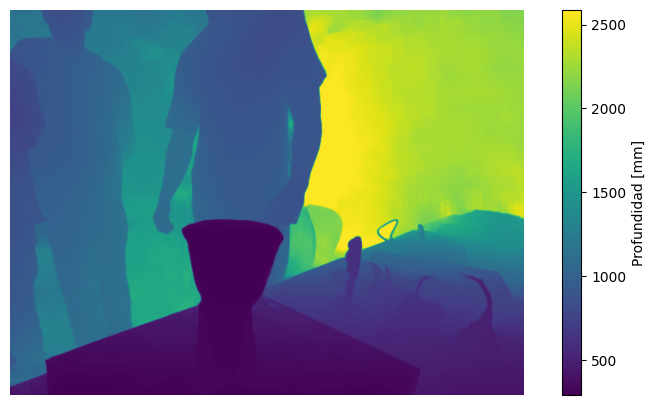

(i) POSE OK. Posición de cámara (X,Y,Z en milimetros): [ 343.07  423.75 -244.54]
(i) PUNTOS 3D generados en este frame: 480000

--- Procesando Frame 16/17 ---


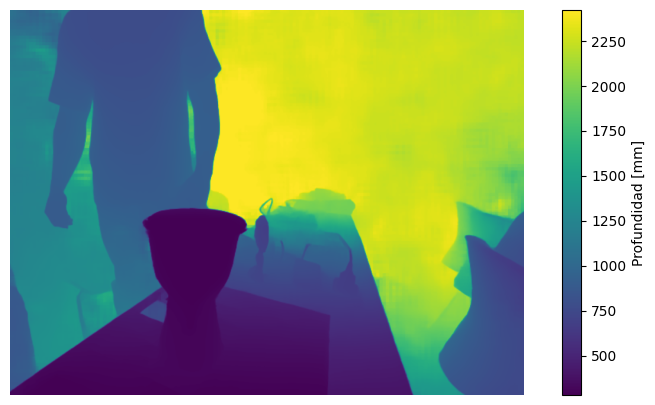

(i) POSE OK. Posición de cámara (X,Y,Z en milimetros): [ 255.53  468.53 -243.38]
(i) PUNTOS 3D generados en este frame: 480000

--- Procesando Frame 17/17 ---


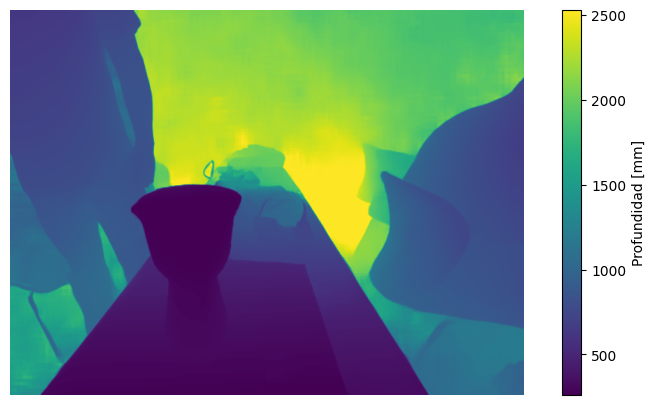

(i) POSE OK. Posición de cámara (X,Y,Z en milimetros): [ 194.61  471.15 -246.3 ]
(i) PUNTOS 3D generados en este frame: 480000
Combinando nubes de puntos...
Puntos guardados en: datasets/stereo_tambor/data/results/points.npy
Poses guardadas en: datasets/stereo_tambor/data/results/poses.npy


In [9]:
reconstruction_from_dataset(dataset_name)

In [10]:
import numpy as np
import open3d as o3d
import json
import pickle
from pathlib import Path

DATASETS_PATH = "datasets"

print("Cargando parámetros de calibración (JSON y PKL)...")
json_path = f"{DATASETS_PATH}/{dataset_name}/data/rect/stereo_calibration.json"
maps_path = f"{DATASETS_PATH}/{dataset_name}/data/stereo_maps.pkl"

with open(json_path, "r") as f:
    data = json.load(f)
with open(maps_path, "rb") as f:
    maps = pickle.load(f)

rectified_K = maps['P1'][:, :3]
IMAGE_WIDTH = data['width']
IMAGE_HEIGHT = data['height']

points_filename = f"{DATASETS_PATH}/{dataset_name}/data/results/points.npy"
poses_filename = f"{DATASETS_PATH}/{dataset_name}/data/results/poses.npy"

print(f"Cargando puntos desde {points_filename}")
points_array = np.load(points_filename)

print(f"Cargando poses desde {poses_filename}")
poses_array = np.load(poses_filename)

print("Carga completa.")

Cargando parámetros de calibración (JSON y PKL)...
Cargando puntos desde datasets/stereo_tambor/data/results/points.npy
Cargando poses desde datasets/stereo_tambor/data/results/poses.npy
Carga completa.


In [11]:
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points_array)

In [12]:
camera_geometries = []

for o_T_c in poses_array:
    camera_viz = o3d.geometry.LineSet.create_camera_visualization(
        IMAGE_WIDTH,
        IMAGE_HEIGHT,
        rectified_K,
        np.linalg.inv(o_T_c),
        scale=100
    )
    camera_geometries.append(camera_viz)

world_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(
    size=200, origin=[0, 0, 0]
)

In [13]:
o3d.visualization.draw_plotly([world_frame] + camera_geometries)

In [14]:
min_bound = np.array([30, 120, -190.2406])
max_bound = np.array([210.4005, 282.3002, -10.0915])

tambor_box = o3d.geometry.AxisAlignedBoundingBox(min_bound, max_bound)

In [15]:
indices_in_box = tambor_box.get_point_indices_within_bounding_box(pcd.points)
tambor_pcd = pcd.select_by_index(indices_in_box)

print(f"Puntos después del recorte: {len(tambor_pcd.points)}")

o3d.io.write_point_cloud(f"{DATASETS_PATH}/{dataset_name}/data/results/tambor-pcd.ply", tambor_pcd)

Puntos después del recorte: 435037


True

In [16]:
nbn = 20
std_ratio = 1

tambor_pcd_cleaned, ind = tambor_pcd.remove_statistical_outlier(
    nb_neighbors=nbn, std_ratio=std_ratio
)

print(f"Puntos finales después de la limpieza: {len(tambor_pcd_cleaned.points)}")
o3d.io.write_point_cloud(f"{DATASETS_PATH}/{dataset_name}/data/results/tambor-pcd-cleaned.ply", tambor_pcd_cleaned)

Puntos finales después de la limpieza: 423288


True